# PCA of NPD summary statistics

Saikat Banerjee  
2023-05-16

# About

For multi-trait analysis of GWAS summary statistics, we look at one of
the simplest models - the principal component analysis (PCA). The goal
is to characterize the latent components of genetic associations. We
apply PCA to the matrix of summary statistics derived from GWAS across
80 NPD phenotypes from various sources – namely, GTEx, OpenGWAS and PGC.
For a similar comprehensive study with the UK Biobank data, see
[Tanigawa et al., Nat. Comm.
2019](https://doi.org/10.1038/s41467-019-11953-9).

The $\mathbf{X}$ matrix of size $N \times P$ for the PCA is
characterized by $N$ phenotypes (samples) and $P$ variants (features).

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from pymir import mpl_stylesheet
from pymir import mpl_utils

from sklearn.decomposition import PCA

mpl_stylesheet.banskt_presentation(splinecolor = 'black', dpi = 120, colors = 'kelly')

# Read summary statistics

In [2]:
data_dir = "../data"
beta_df_filename = f"{data_dir}/beta_df.pkl"
prec_df_filename = f"{data_dir}/prec_df.pkl"
beta_df = pd.read_pickle(beta_df_filename)
prec_df = pd.read_pickle(prec_df_filename)

trait_df = pd.read_csv(f"{data_dir}/trait_meta.csv")
phenotype_dict = trait_df.set_index('ID')['Broad'].to_dict()

After [filtering](preprocess_npd_gtex_pgc_ieu.ipynb), there are 8403
variants for 80 phenotypes, summarized below.

In [3]:
beta_df

8403 rows × 80 columns

# Filter samples (phenotypes)

To eliminate unreliable estimates of genetic associations, we remove
samples (phenotypes) whose mean standard error (SE) of beta value or log
odds ratio is less than 0.2. The mean SE for all the 80 phenotypes are
shown in [Figure 1](#fig-se-vs-beta-std)

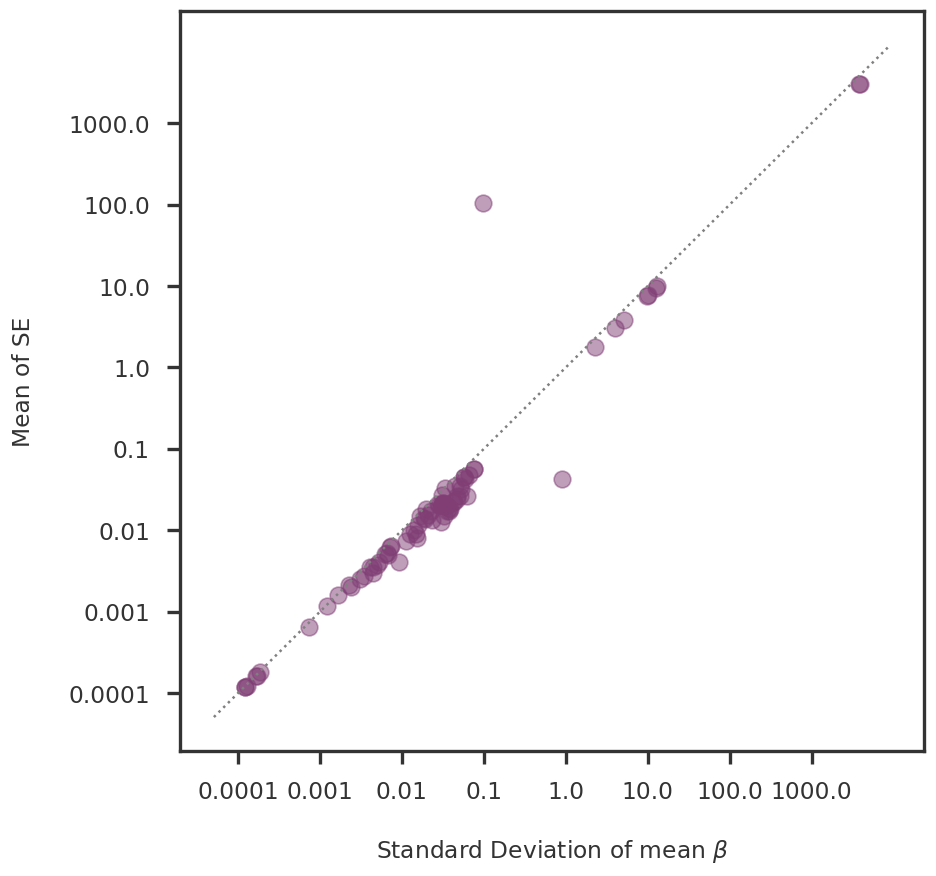

In [4]:
mean_se = prec_df.apply(lambda x : 1 / np.sqrt(x)).replace([np.inf, -np.inf], np.nan).mean(axis = 0, skipna = True)
mean_se = pd.DataFrame(mean_se).set_axis(["mean_se"], axis = 1)
beta_std = beta_df.std(axis = 0, skipna = True)
beta_std = pd.DataFrame(beta_std).set_axis(["beta_std"], axis = 1)
error_df = pd.concat([mean_se, beta_std], axis = 1)

fig = plt.figure()
ax1 = fig.add_subplot(111)
ax1.scatter(np.log10(error_df['beta_std']), np.log10(error_df['mean_se']), alpha = 0.5, s = 100)
mpl_utils.set_xticks(ax1, scale = 'log10', spacing = 'log10')
mpl_utils.set_yticks(ax1, scale = 'log10', spacing = 'log10')
mpl_utils.plot_diag(ax1)
ax1.set_xlabel(r"Standard Deviation of mean $\beta$")
ax1.set_ylabel(r"Mean of SE")
plt.show()

In [5]:
select_ids = error_df.query("mean_se <= 0.2 and beta_std <= 0.2").index

# PCA

We use the z-score as the observation statistic for each phenotype and
variant. For PCA, we center the columns of the X matrix.

In [6]:
se_df = prec_df.apply(lambda x : 1 / np.sqrt(x)).replace([np.inf, -np.inf], np.nan)

zscore_df = beta_df / se_df
zscore_df = zscore_df.replace(np.nan, 0)
X = np.array(zscore_df[select_ids]).T
colmeans = np.mean(X, axis = 0, keepdims = True)
Xcent = X - colmeans

labels = [phenotype_dict[x] for x in select_ids]
unique_labels = list(set(labels))

print (f"We have {Xcent.shape[0]} samples (phenotypes) and {Xcent.shape[1]} features (variants)")

We have 69 samples (phenotypes) and 8403 features (variants)

In [7]:
ncomp = min(Xcent.shape)
pca = PCA(n_components = ncomp)
pca.fit(Xcent)
beta_pcs = pca.fit_transform(Xcent)
beta_eig  = pca.components_

The variance explained by each principal component is shown in
[Figure 2](#fig-pca-variance-explained)

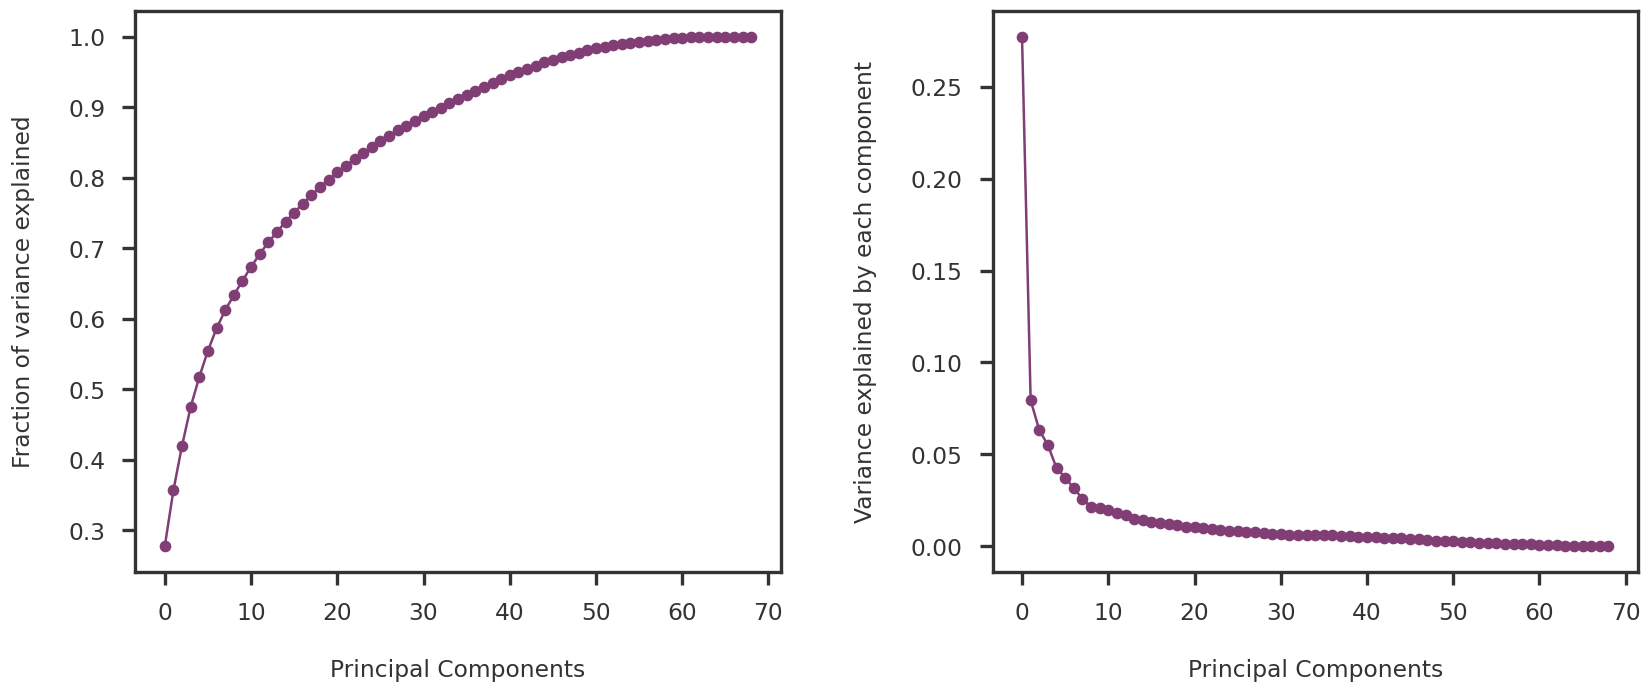

In [8]:
fig = plt.figure(figsize = (14, 6))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

#ax1.scatter(np.arange(ncomp), pca.explained_variance_ratio_, s = 100, alpha = 0.7)
ax1.plot(np.arange(ncomp), np.cumsum(pca.explained_variance_ratio_), marker = 'o')
ax1.set_ylabel("Fraction of variance explained")
ax1.set_xlabel("Principal Components")

ax2.plot(np.arange(ncomp), pca.explained_variance_ratio_, marker = 'o')
ax2.set_ylabel("Variance explained by each component")
ax2.set_xlabel("Principal Components")

plt.tight_layout(w_pad = 3)
plt.show()

We plot the first 6 principal components against each other in
[Figure 3](#fig-pca-compare-components). Each dot is a sample
(phenotype) colored by their broad label of NPD.

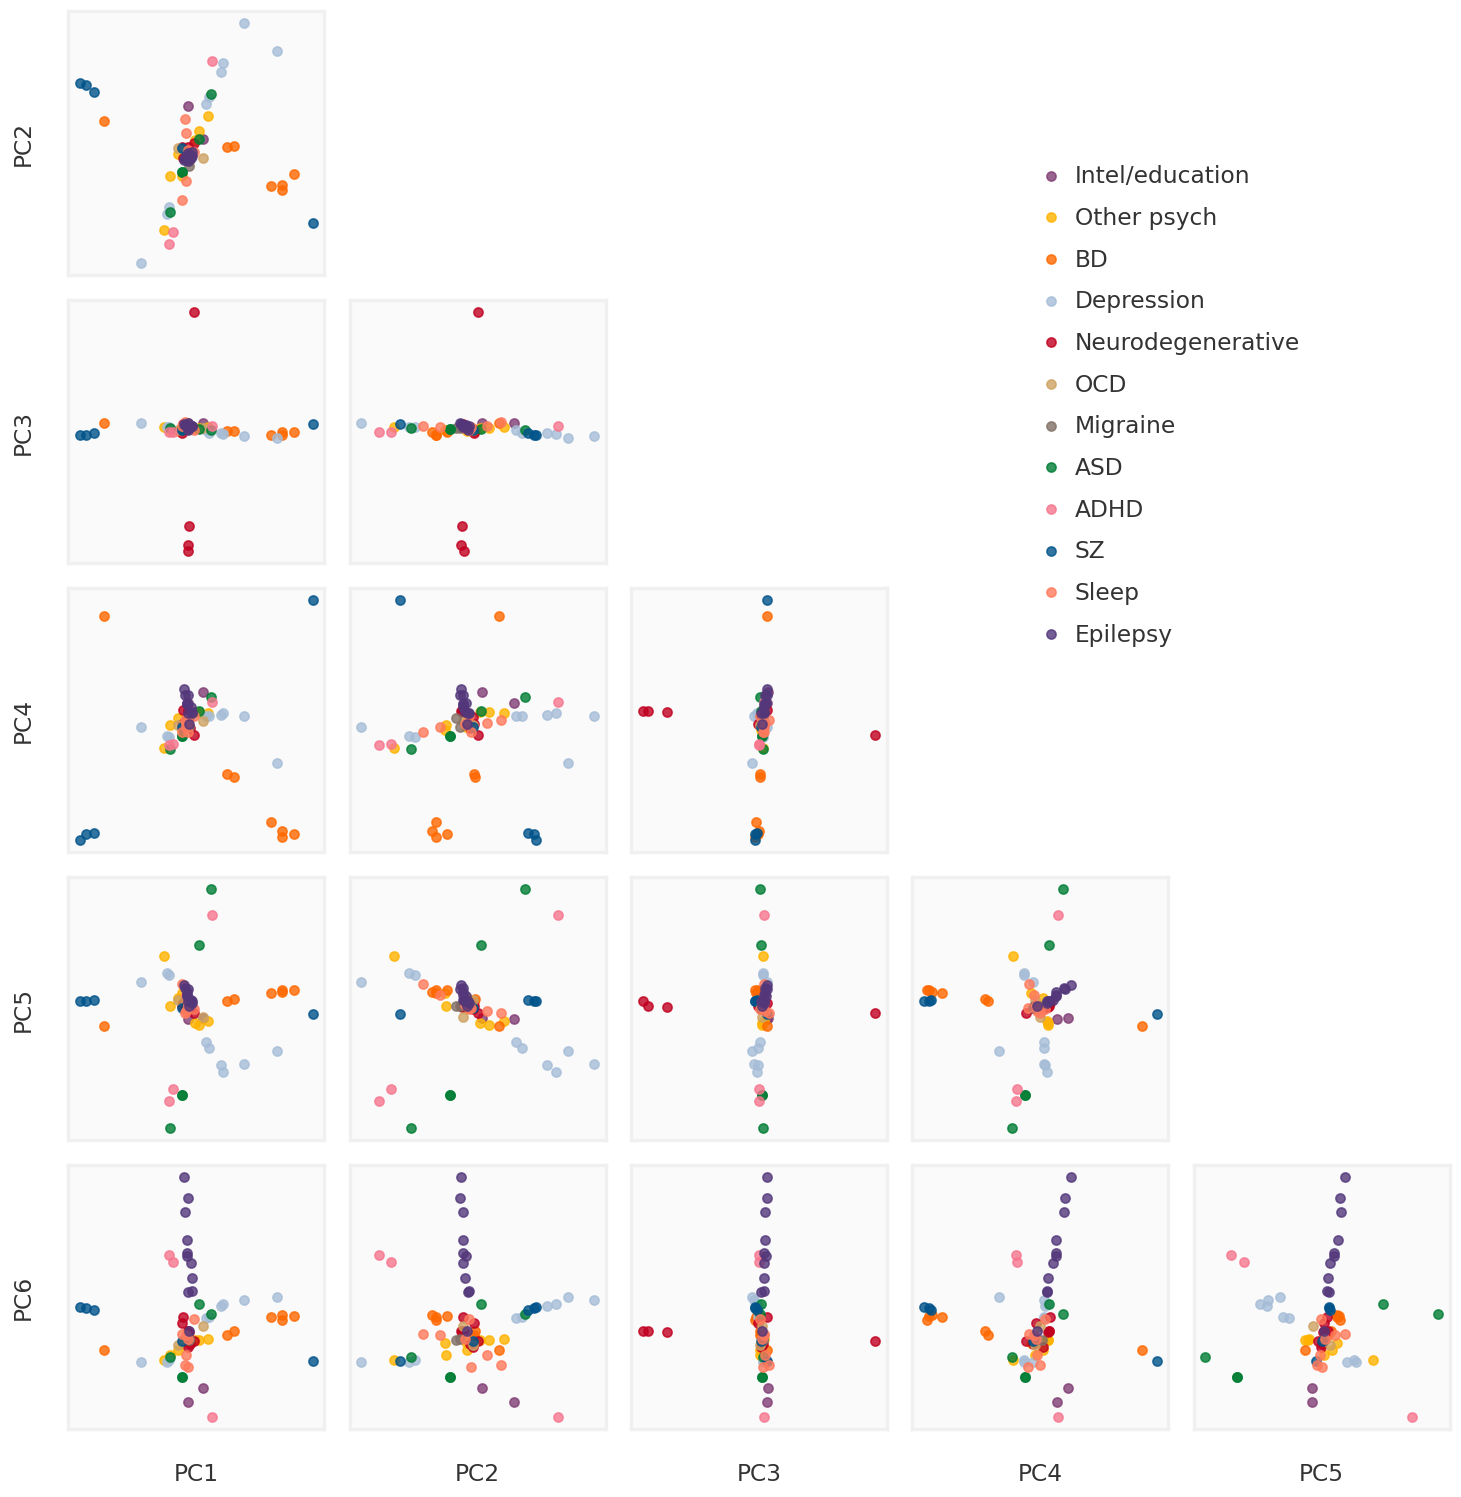

In [9]:
plot_ncomp = 6
subplot_h = 2.0

nrow = plot_ncomp - 1
ncol = plot_ncomp - 1
figw = ncol * subplot_h + (ncol - 1) * 0.3 + 1.2
figh = nrow * subplot_h + (nrow - 1) * 0.3 + 1.5
bgcolor = '#F0F0F0'


def make_plot_principal_components(ax, i, j, comp):
    pc1 = comp[:, j]
    pc2 = comp[:, i]
    for label in unique_labels:
        idx = np.array([k for k, x in enumerate(labels) if x == label])
        ax.scatter(pc1[idx], pc2[idx], s = 30, alpha = 0.8, label = label)
    return

fig = plt.figure(figsize = (figw, figh))
axmain = fig.add_subplot(111)

for i in range(1, nrow + 1):
    for j in range(ncol):
        ax = fig.add_subplot(nrow, ncol, ((i - 1) * ncol) + j + 1)
        
        ax.tick_params(bottom = False, top = False, left = False, right = False,
                       labelbottom = False, labeltop = False, labelleft = False, labelright = False)
        if j == 0: ax.set_ylabel(f"PC{i + 1}")
        if i == nrow: ax.set_xlabel(f"PC{j + 1}")
        if i > j:
            ax.patch.set_facecolor(bgcolor)
            ax.patch.set_alpha(0.3)
            make_plot_principal_components(ax, i, j, beta_pcs)
            for side, border in ax.spines.items():
                border.set_color(bgcolor)
        else:
            ax.patch.set_alpha(0.)
            for side, border in ax.spines.items():
                border.set_visible(False)
                
        if i == 1 and j == 0:
            mhandles, mlabels = ax.get_legend_handles_labels()

axmain.tick_params(bottom = False, top = False, left = False, right = False,
                   labelbottom = False, labeltop = False, labelleft = False, labelright = False)
for side, border in axmain.spines.items():
    border.set_visible(False)
axmain.legend(handles = mhandles, labels = mlabels, loc = 'upper right', bbox_to_anchor = (0.9, 0.9))
          
        
plt.tight_layout()
plt.show()

# PCA using SVD

Just to make sure that I understand things correctly, I am redoing the
PCA using SVD. It must yield the same results as `sklearn PCA`. Indeed,
it does as shown in [Figure 4](#fig-pca-svd-check).

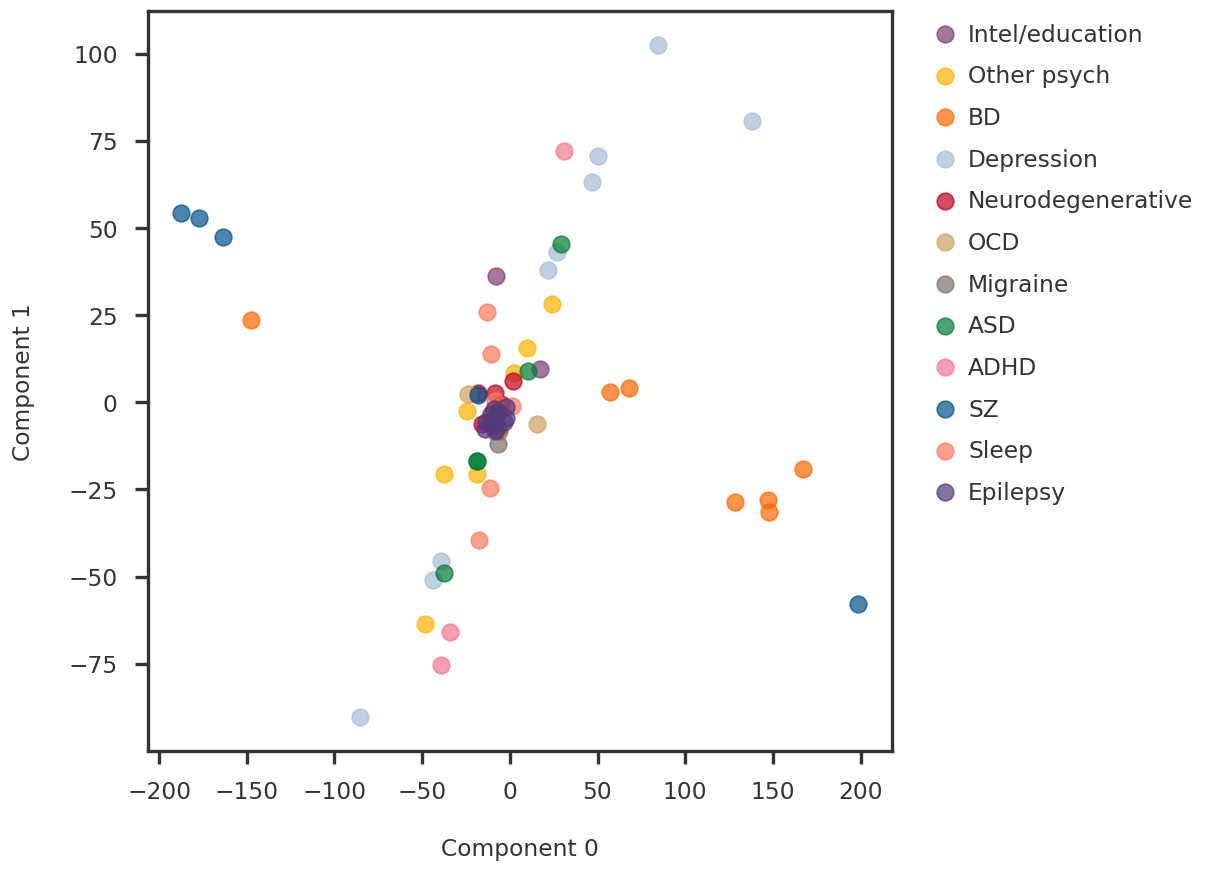

In [10]:
U, S, Vt = np.linalg.svd(Xcent, full_matrices=False)
svd_pcs = U @ np.diag(S)

idx1 = 0
idx2 = 1
svd_pc1 = svd_pcs[:, idx1]
svd_pc2 = svd_pcs[:, idx2]

fig = plt.figure()
ax1 = fig.add_subplot(111)

for label in unique_labels:
    idx = np.array([i for i, x in enumerate(labels) if x == label])
    ax1.scatter(- svd_pc1[idx], - svd_pc2[idx], s = 100, alpha = 0.7, label = label)
    
ax1.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
ax1.set_xlabel(f"Component {idx1}")
ax1.set_ylabel(f"Component {idx2}")
plt.show()

# Weighted PCA

Here, I implement the weighted covariance eigendecomposition approach
algorithm proposed by [L. Delchambre
(2014)](https://doi.org/10.1093/mnras/stu2219). I used 3 different
versions of the weight matrix:

-   the identity matrix (to check that the implementation is correct).
-   the precision matrix (as suggested by David in the project
    proposal).
-   square root of the precision (ad-hoc idea to reduce the weights on
    each observation)

In [11]:
# W = np.ones(X.shape)
# W = np.array(prec_df[select_ids]).T
W = np.sqrt(np.array(prec_df[select_ids]).T)

In [12]:
def weighted_mean(x, w=None, axis=None):
    """Compute the weighted mean along the given axis

    The result is equivalent to (x * w).sum(axis) / w.sum(axis),
    but large temporary arrays are not created.

    Parameters
    ----------
    x : array_like
        data for which mean is computed
    w : array_like (optional)
        weights corresponding to each data point. If supplied, it must be the
        same shape as x
    axis : int or None (optional)
        axis along which mean should be computed

    Returns
    -------
    mean : np.ndarray
        array representing the weighted mean along the given axis
    """
    if w is None:
        return np.mean(x, axis)

    x = np.asarray(x)
    w = np.asarray(w)

    if x.shape != w.shape:
        raise NotImplementedError("Broadcasting is not implemented: "
                                  "x and w must be the same shape.")

    if axis is None:
        wx_sum = np.einsum('i,i', np.ravel(x), np.ravel(w))
    else:
        try:
            axis = tuple(axis)
        except TypeError:
            axis = (axis,)

        if len(axis) != len(set(axis)):
            raise ValueError("duplicate value in 'axis'")

        trans = sorted(set(range(x.ndim)).difference(axis)) + list(axis)
        operand = "...{0},...{0}".format(''.join(chr(ord('i') + i)
                                                 for i in range(len(axis))))
        wx_sum = np.einsum(operand,
                           np.transpose(x, trans),
                           np.transpose(w, trans))

    return wx_sum / np.sum(w, axis)

def weighted_pca_delchambre(X, W, n_components = None, regularization = None):
    
    import scipy as sp
    
    weights = weighted_mean(X, W, axis = 0).reshape(1, -1)
    _X = (X - weights) *  weights
    _covar = np.dot(_X.T, _X)
    _covar /= np.dot(weights.T, weights)
    _covar[np.isnan(_covar)] = 0

    n_components = 20
    eigvals = (_X.shape[1] - n_components, _X.shape[1] - 1)
    evals, evecs = sp.linalg.eigh(_covar, subset_by_index = eigvals)

    components = evecs[:, ::-1].T
    explained_variance = evals[::-1]
    Y = np.zeros((_X.shape[0], components.shape[0]))
    for i in range(_X.shape[0]):
        cW = components * weights[0, i]
        cWX = np.dot(cW, _X[i])
        cWc = np.dot(cW, cW.T)
        if regularization is not None:
            cWc += np.diag(regularization / explained_variance)
        Y[i] = np.linalg.solve(cWc, cWX)
    return Y, explained_variance

In [13]:
weighted_pcs, explained_variance = weighted_pca_delchambre(Xcent, W, n_components = 20, regularization = None)

As before, the variance explained by each principal component is shown
in [Figure 5](#fig-wpca-variance-explained)

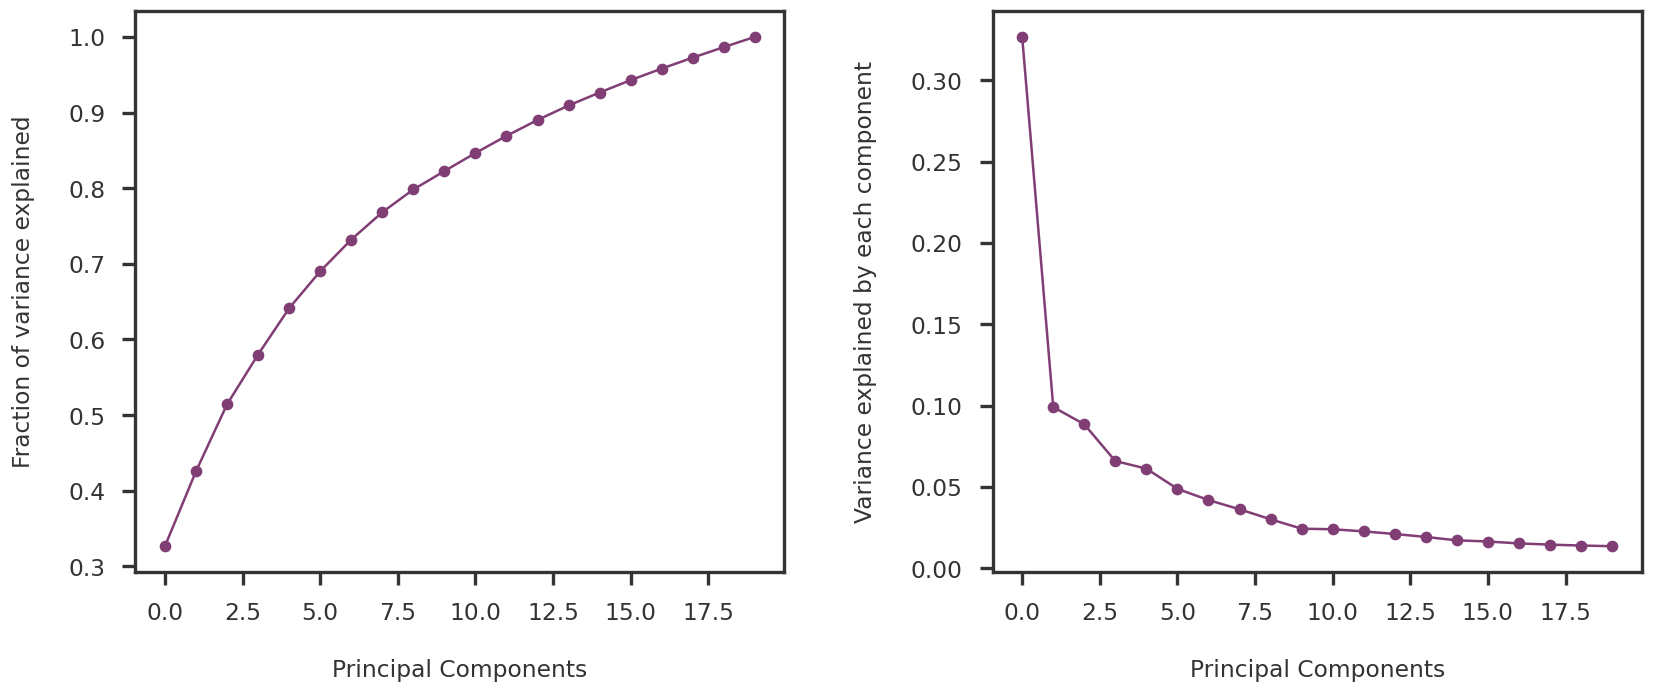

In [14]:
wpca_tot_explained_variance = np.sum(explained_variance)
wpca_explained_variance_ratio = explained_variance / wpca_tot_explained_variance

fig = plt.figure(figsize = (14, 6))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(np.arange(20), np.cumsum(wpca_explained_variance_ratio), marker = 'o')
ax1.set_ylabel("Fraction of variance explained")
ax1.set_xlabel("Principal Components")

ax2.plot(np.arange(20), wpca_explained_variance_ratio, marker = 'o')
ax2.set_ylabel("Variance explained by each component")
ax2.set_xlabel("Principal Components")

plt.tight_layout(w_pad = 3)
plt.show()

We plot the first 6 principal components against each other in
[Figure 6](#fig-wpca-compare-components). Each dot is a sample
(phenotype) colored by their broad label of NPD.

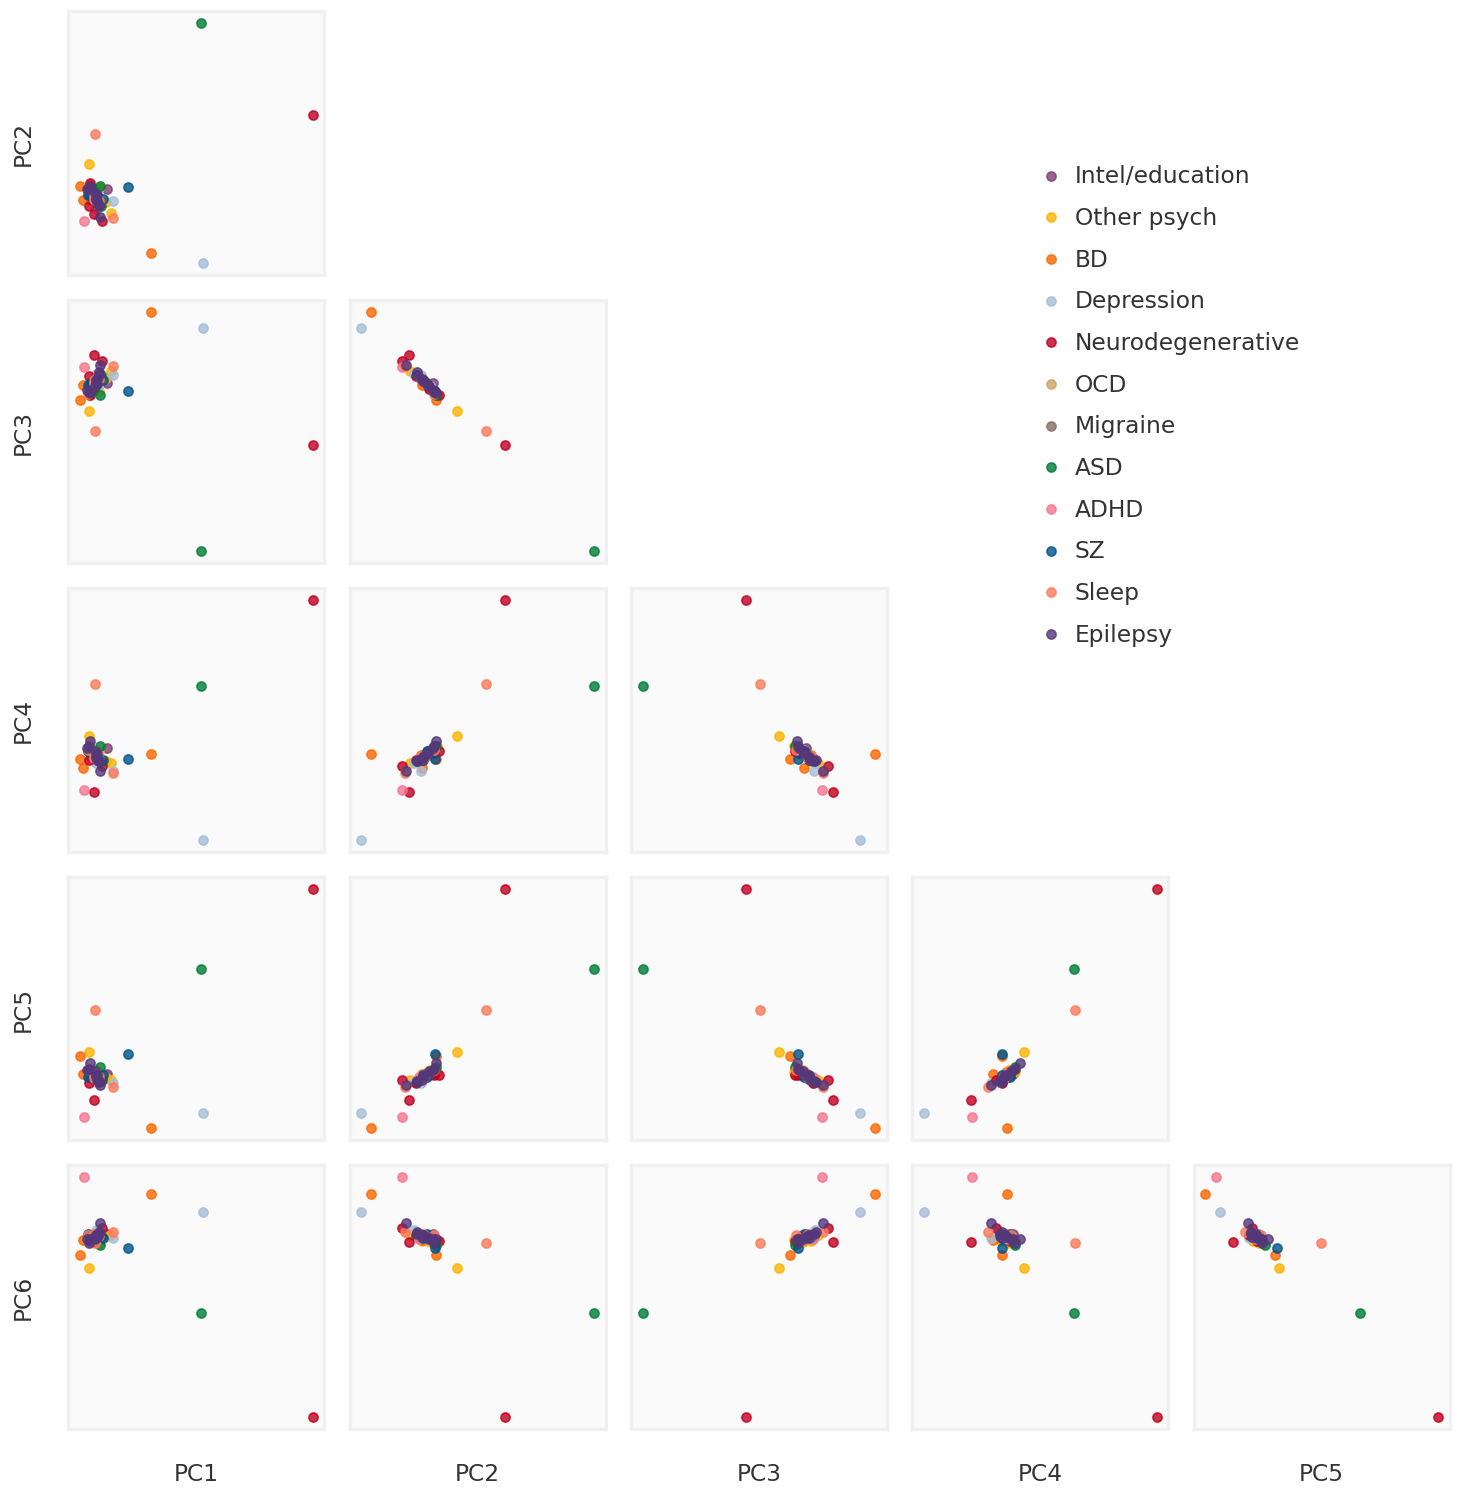

In [15]:
plot_ncomp = 6
subplot_h = 2.0

nrow = plot_ncomp - 1
ncol = plot_ncomp - 1
figw = ncol * subplot_h + (ncol - 1) * 0.3 + 1.2
figh = nrow * subplot_h + (nrow - 1) * 0.3 + 1.5
bgcolor = '#F0F0F0'


def make_plot_principal_components(ax, i, j, comp):
    pc1 = comp[:, j]
    pc2 = comp[:, i]
    for label in unique_labels:
        idx = np.array([k for k, x in enumerate(labels) if x == label])
        ax.scatter(pc1[idx], pc2[idx], s = 30, alpha = 0.8, label = label)
    return

fig = plt.figure(figsize = (figw, figh))
axmain = fig.add_subplot(111)

for i in range(1, nrow + 1):
    for j in range(ncol):
        ax = fig.add_subplot(nrow, ncol, ((i - 1) * ncol) + j + 1)
        
        ax.tick_params(bottom = False, top = False, left = False, right = False,
                       labelbottom = False, labeltop = False, labelleft = False, labelright = False)
        if j == 0: ax.set_ylabel(f"PC{i + 1}")
        if i == nrow: ax.set_xlabel(f"PC{j + 1}")
        if i > j:
            ax.patch.set_facecolor(bgcolor)
            ax.patch.set_alpha(0.3)
            make_plot_principal_components(ax, i, j, weighted_pcs)
            for side, border in ax.spines.items():
                border.set_color(bgcolor)
        else:
            ax.patch.set_alpha(0.)
            for side, border in ax.spines.items():
                border.set_visible(False)
                
        if i == 1 and j == 0:
            mhandles, mlabels = ax.get_legend_handles_labels()

axmain.tick_params(bottom = False, top = False, left = False, right = False,
                   labelbottom = False, labeltop = False, labelleft = False, labelright = False)
for side, border in axmain.spines.items():
    border.set_visible(False)
axmain.legend(handles = mhandles, labels = mlabels, loc = 'upper right', bbox_to_anchor = (0.9, 0.9))
          
        
plt.tight_layout()
plt.show()

# Further Reading

-   [Comments on PCA by Alex
    Williams](http://alexhwilliams.info/itsneuronalblog/2016/03/27/pca/)